# Semantic Similarity Analysis: AI-Generated Descriptions vs. Literary Corpora

## Research Question
Are AI-generated location and structure descriptions semantically closer to:
- (A) William Morris's literary fantasy prose (*The Well at the World's End*, 1896)
- (B) The D&D System Reference Document 5.2.1 (game rules)

## Method
1. Combine `locations.txt` and `structures.txt` into `combined.txt`
2. Compare `combined.txt` against `morris_descriptive.txt` and `srd_descriptive.txt`
3. Use **Document Centroid Cosine Similarity** with word2vec embeddings
4. Visualize results with scatter plots

## 1. Setup and Imports

In [1]:
import re, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import gensim.downloader as gensim_dl
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

STOP_WORDS = set(stopwords.words('english'))

print('Imports complete.')

Imports complete.


## 2. Load Pre-trained Word Embeddings

Using **GloVe-wiki-gigaword-100** (100-dimensional vectors trained on Wikipedia + Gigaword)

In [2]:
print('Loading GloVe-wiki-gigaword-100 (downloads ~120 MB on first run)...')
wv = gensim_dl.load('glove-wiki-gigaword-100')
print(f'Model loaded. Vocabulary size: {len(wv):,}  |  Vector dimensions: {wv.vector_size}')

Loading GloVe-wiki-gigaword-100 (downloads ~120 MB on first run)...
Model loaded. Vocabulary size: 400,000  |  Vector dimensions: 100


## 3. Parse Reference Corpora

Load Morris and SRD descriptive passages

In [3]:
def parse_descriptive_file(path, source_label):
    """Parse morris_descriptive.txt or srd_descriptive.txt format.
    Returns a list of {'source': label, 'text': passage_text} dicts.
    """
    with open(path, 'r', encoding='utf-8') as f:
        raw = f.read()
    
    # Split on separator lines
    blocks = re.split(r'-{6,}', raw)
    passages = []
    
    for block in blocks:
        block = block.strip()
        if not block or len(block) < 50:
            continue
        
        # Extract the passage text (after the Score/metadata line)
        text_match = re.search(r'Score:.*?\n\n(.+)', block, re.DOTALL)
        if text_match:
            text = text_match.group(1).strip()
            if len(text.split()) > 10:
                passages.append({'source': source_label, 'text': text})
    
    return passages

morris_docs = parse_descriptive_file('morris_descriptive.txt', 'Morris')
srd_docs = parse_descriptive_file('srd_descriptive.txt', 'SRD')

print(f'Morris passages loaded: {len(morris_docs)}')
print(f'SRD passages loaded:    {len(srd_docs)}')

Morris passages loaded: 76
SRD passages loaded:    147


## 4. Combine Locations and Structures

Parse `locations.txt` and `structures.txt`, combine them, and save to `combined.txt`

In [4]:
def parse_pipe_table(path):
    """Parse pipe-delimited table (name | description format)."""
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('-'):
                continue
            parts = line.split('|')
            if len(parts) < 2:
                continue
            name = parts[0].strip()
            desc = parts[1].strip()
            # Skip header rows
            if name.lower() in ('name', 'structure_name') or 'description' in desc.lower()[:20]:
                continue
            if len(desc.split()) > 5:
                rows.append({'name': name, 'description': desc})
    return rows

locations = parse_pipe_table('locations.txt')
structures = parse_pipe_table('structures.txt')

print(f'Locations loaded:  {len(locations)}')
print(f'Structures loaded: {len(structures)}')

# Combine and save to combined.txt
combined = locations + structures

with open('combined.txt', 'w', encoding='utf-8') as f:
    f.write('AI-GENERATED LOCATION AND STRUCTURE DESCRIPTIONS\n')
    f.write(f'Total entries: {len(combined)}\n')
    f.write('=' * 70 + '\n\n')
    
    for i, item in enumerate(combined, 1):
        f.write(f'[{i}] {item["name"]}\n\n')
        f.write(f'{item["description"]}\n')
        f.write('\n' + '-' * 70 + '\n\n')

print(f'\nCombined file created: combined.txt ({len(combined)} total descriptions)')

# Create combined docs list for processing
combined_docs = [{'source': 'Combined', 'text': item['description']} for item in combined]
print(f'Combined docs ready: {len(combined_docs)}')

Locations loaded:  492
Structures loaded: 146

Combined file created: combined.txt (638 total descriptions)
Combined docs ready: 638


## 5. Text Preprocessing

Tokenize, remove stopwords, and filter to vocabulary words

In [5]:
def preprocess(text):
    """Tokenize, lowercase, remove stopwords, keep only words in vocabulary."""
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in STOP_WORDS]
    tokens = [t for t in tokens if t in wv]
    return tokens

# Preprocess all documents
for doc in morris_docs + srd_docs + combined_docs:
    doc['tokens'] = preprocess(doc['text'])

# Report statistics
print('Preprocessing complete:\n')
for collection, name in [(morris_docs, 'Morris'), (srd_docs, 'SRD'), (combined_docs, 'Combined')]:
    total_tokens = sum(len(d['tokens']) for d in collection)
    avg_tokens = total_tokens / len(collection) if collection else 0
    print(f'{name:10s}: {len(collection):3d} docs, {total_tokens:5,d} tokens (avg {avg_tokens:.1f} per doc)')

Preprocessing complete:

Morris    :  76 docs, 2,490 tokens (avg 32.8 per doc)
SRD       : 147 docs, 3,644 tokens (avg 24.8 per doc)
Combined  : 638 docs, 10,308 tokens (avg 16.2 per doc)


## 6. Create Document Vectors

Represent each document as the mean of its word vectors (document centroid)

In [6]:
def document_vector(tokens):
    """Return the mean word vector for a token list, or None if empty."""
    vecs = [wv[t] for t in tokens if t in wv]
    if not vecs:
        return None
    return np.mean(vecs, axis=0)

# Add vectors to all documents, filter out empty ones
def add_vectors(docs):
    valid = []
    for doc in docs:
        vec = document_vector(doc['tokens'])
        if vec is not None:
            doc['vector'] = vec
            valid.append(doc)
    return valid

morris_docs = add_vectors(morris_docs)
srd_docs = add_vectors(srd_docs)
combined_docs = add_vectors(combined_docs)

print('Document vectors created:\n')
print(f'Morris:   {len(morris_docs)} documents')
print(f'SRD:      {len(srd_docs)} documents')
print(f'Combined: {len(combined_docs)} documents')

Document vectors created:

Morris:   76 documents
SRD:      147 documents
Combined: 638 documents


## 7. Calculate Corpus Centroids

Create a single centroid vector for each reference corpus (Morris and SRD)

In [7]:
def corpus_centroid(docs):
    """Calculate the mean of all document vectors in a collection."""
    vecs = np.array([d['vector'] for d in docs])
    return np.mean(vecs, axis=0)

morris_centroid = corpus_centroid(morris_docs)
srd_centroid = corpus_centroid(srd_docs)

# How similar are Morris and SRD to each other?
inter_corpus_sim = cosine_similarity(
    morris_centroid.reshape(1, -1),
    srd_centroid.reshape(1, -1)
)[0][0]

print(f'Morris corpus centroid created')
print(f'SRD corpus centroid created')
print(f'\nMorris-SRD inter-corpus similarity: {inter_corpus_sim:.4f}')
print('(High similarity indicates overlapping vocabulary domains)')

Morris corpus centroid created
SRD corpus centroid created

Morris-SRD inter-corpus similarity: 0.9328
(High similarity indicates overlapping vocabulary domains)


## 8. Calculate Similarities

Compare each Combined document against both Morris and SRD centroids

In [8]:
def calculate_similarities(docs, morris_cent, srd_cent):
    """Calculate cosine similarity to both reference centroids."""
    results = []
    for doc in docs:
        vec = doc['vector'].reshape(1, -1)
        sim_morris = cosine_similarity(vec, morris_cent.reshape(1, -1))[0][0]
        sim_srd = cosine_similarity(vec, srd_cent.reshape(1, -1))[0][0]
        results.append({
            'text': doc['text'][:60],
            'sim_Morris': sim_morris,
            'sim_SRD': sim_srd,
            'delta': sim_morris - sim_srd  # positive = more Morris-like
        })
    return pd.DataFrame(results)

df_combined = calculate_similarities(combined_docs, morris_centroid, srd_centroid)

print('Similarity calculations complete:\n')
print(df_combined[['sim_Morris', 'sim_SRD', 'delta']].describe().round(4))

Similarity calculations complete:

       sim_Morris   sim_SRD     delta
count    638.0000  638.0000  638.0000
mean       0.8031    0.8165   -0.0133
std        0.0953    0.1005    0.0293
min        0.3145    0.2943   -0.1110
25%        0.7618    0.7689   -0.0312
50%        0.8336    0.8518   -0.0175
75%        0.8595    0.8774    0.0015
max        0.9408    0.9370    0.1012


## 9. Scatter Plot: Combined vs Morris and SRD

Visualize how each Combined description relates to both reference corpora

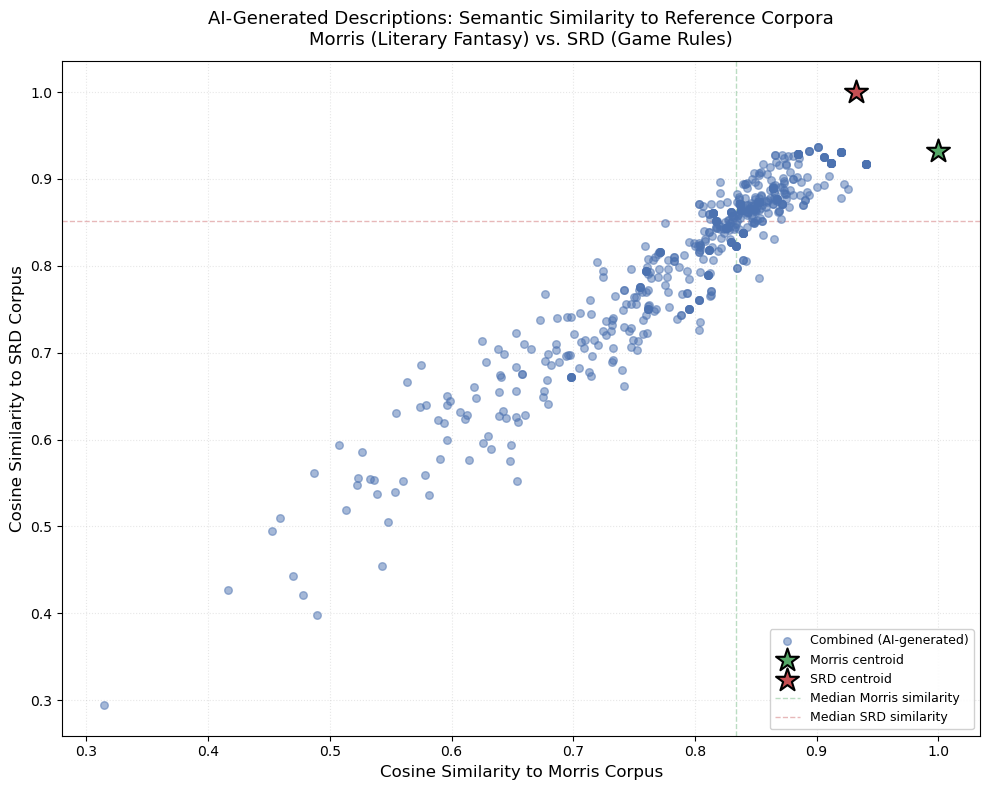


Saved: similarity_scatter.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot Combined descriptions
ax.scatter(
    df_combined['sim_Morris'], 
    df_combined['sim_SRD'],
    c='#4C72B0', 
    s=30, 
    alpha=0.5,
    label='Combined (AI-generated)',
    zorder=3
)

# Add reference corpus centroids
# Morris centroid compared to itself and SRD
morris_self_sim = cosine_similarity(
    morris_centroid.reshape(1, -1),
    morris_centroid.reshape(1, -1)
)[0][0]
morris_to_srd = cosine_similarity(
    morris_centroid.reshape(1, -1),
    srd_centroid.reshape(1, -1)
)[0][0]
ax.scatter(morris_self_sim, morris_to_srd, c='#55A868', s=300, marker='*', 
           edgecolors='black', linewidth=1.5, label='Morris centroid', zorder=5)

# SRD centroid compared to Morris and itself
srd_to_morris = cosine_similarity(
    srd_centroid.reshape(1, -1),
    morris_centroid.reshape(1, -1)
)[0][0]
srd_self_sim = cosine_similarity(
    srd_centroid.reshape(1, -1),
    srd_centroid.reshape(1, -1)
)[0][0]
ax.scatter(srd_to_morris, srd_self_sim, c='#C44E52', s=300, marker='*', 
           edgecolors='black', linewidth=1.5, label='SRD centroid', zorder=5)

# Add reference lines at median values
ax.axvline(df_combined['sim_Morris'].median(), color='#55A868', 
           linestyle='--', alpha=0.4, linewidth=1, label='Median Morris similarity')
ax.axhline(df_combined['sim_SRD'].median(), color='#C44E52', 
           linestyle='--', alpha=0.4, linewidth=1, label='Median SRD similarity')

# Labels and formatting
ax.set_xlabel('Cosine Similarity to Morris Corpus', fontsize=12)
ax.set_ylabel('Cosine Similarity to SRD Corpus', fontsize=12)
ax.set_title('AI-Generated Descriptions: Semantic Similarity to Reference Corpora\n'
             'Morris (Literary Fantasy) vs. SRD (Game Rules)', fontsize=13, pad=12)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.savefig('similarity_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSaved: similarity_scatter.png')

## 10. Summary Statistics

In [10]:
print('='*70)
print('SUMMARY: AI-Generated Descriptions vs. Reference Corpora')
print('='*70)
print(f'\nTotal AI-generated descriptions analyzed: {len(df_combined)}')
print(f'Reference corpus sizes: Morris={len(morris_docs)}, SRD={len(srd_docs)}')
print()

print('Similarity to Morris (literary fantasy):')
print(f'  Mean:   {df_combined["sim_Morris"].mean():.4f}')
print(f'  Median: {df_combined["sim_Morris"].median():.4f}')
print(f'  Std:    {df_combined["sim_Morris"].std():.4f}')
print()

print('Similarity to SRD (game rules):')
print(f'  Mean:   {df_combined["sim_SRD"].mean():.4f}')
print(f'  Median: {df_combined["sim_SRD"].median():.4f}')
print(f'  Std:    {df_combined["sim_SRD"].std():.4f}')
print()

print('Delta (Morris - SRD):')
print(f'  Mean:   {df_combined["delta"].mean():.4f}')
print(f'  Median: {df_combined["delta"].median():.4f}')
print()

# Count which corpus is closer
closer_to_morris = (df_combined['delta'] > 0).sum()
closer_to_srd = (df_combined['delta'] < 0).sum()
equal = (df_combined['delta'] == 0).sum()

print(f'Descriptions closer to Morris: {closer_to_morris} ({100*closer_to_morris/len(df_combined):.1f}%)')
print(f'Descriptions closer to SRD:    {closer_to_srd} ({100*closer_to_srd/len(df_combined):.1f}%)')
print(f'Equal distance:                {equal}')
print()

print('='*70)
print('TOP 5 MOST MORRIS-LIKE DESCRIPTIONS')
print('='*70)
top_morris = df_combined.nlargest(5, 'sim_Morris')
for idx, row in top_morris.iterrows():
    print(f"Morris: {row['sim_Morris']:.4f} | SRD: {row['sim_SRD']:.4f}")
    print(f"  {row['text']}...")
    print()

print('='*70)
print('TOP 5 MOST SRD-LIKE DESCRIPTIONS')
print('='*70)
top_srd = df_combined.nlargest(5, 'sim_SRD')
for idx, row in top_srd.iterrows():
    print(f"Morris: {row['sim_Morris']:.4f} | SRD: {row['sim_SRD']:.4f}")
    print(f"  {row['text']}...")
    print()

SUMMARY: AI-Generated Descriptions vs. Reference Corpora

Total AI-generated descriptions analyzed: 638
Reference corpus sizes: Morris=76, SRD=147

Similarity to Morris (literary fantasy):
  Mean:   0.8031
  Median: 0.8336
  Std:    0.0953

Similarity to SRD (game rules):
  Mean:   0.8165
  Median: 0.8518
  Std:    0.1005

Delta (Morris - SRD):
  Mean:   -0.0133
  Median: -0.0175

Descriptions closer to Morris: 172 (27.0%)
Descriptions closer to SRD:    466 (73.0%)
Equal distance:                0

TOP 5 MOST MORRIS-LIKE DESCRIPTIONS
Morris: 0.9408 | SRD: 0.9169
  A large room carved from the living rock, its purpose lost t...

Morris: 0.9408 | SRD: 0.9169
  A large room carved from the living rock, its purpose lost t...

Morris: 0.9408 | SRD: 0.9169
  A large room carved from the living rock, its purpose lost t...

Morris: 0.9408 | SRD: 0.9169
  A large room carved from the living rock, its purpose lost t...

Morris: 0.9408 | SRD: 0.9169
  A large room carved from the living rock, its

## 11. Export Results

Save the similarity data to CSV for further analysis

In [11]:
df_combined.to_csv('similarity_results.csv', index=False)
print('Results saved to: similarity_results.csv')

Results saved to: similarity_results.csv
